# Taller 6: Diseño y Optimización de una CNN
## CIFAR-10

### Contexto del taller
- Materia: Técnicas de Inteligencia Artificial
- Institución: Universidad Nacional de Colombia, Sede Bogotá
- Programa: Ingeniería Mecatrónica
- Enfoque: Aprendizaje profundo para señales espaciales

### Objetivo
Diseñar, justificar, comparar y evaluar una CNN para clasificación multiclase sobre CIFAR-10, integrando preprocesamiento, búsqueda de hiperparámetros, análisis de desempeño y discusión técnica.

## 0. Guía de trabajo y configuración inicial

Este cuaderno implementa un flujo completo de aprendizaje profundo aplicado a CIFAR-10. La metodología sigue un enfoque científico riguroso: desde la exploración de hiperparámetros hasta la evaluación final con métricas estándar de clasificación.

**Secuencia del taller:**
1. Comprender el problema y los datos de CIFAR-10 (estructura, distribución de clases).
2. Preparar el conjunto de entrenamiento, validación y prueba (normalización, estratificación).
3. Diseñar una CNN base con justificación técnica (arquitectura, regularización).
4. Explorar hiperparámetros con una búsqueda controlada (Grid/Random Search).
5. Seleccionar los tres mejores modelos según validación (criterio: `val_accuracy`).
6. Evaluar el mejor modelo en test y analizar sobreajuste (brecha train-val).
7. Comparar contra un MLP tradicional (línea base para ver el impacto de la estructura convolucional).
8. Cerrar con conclusiones argumentadas basadas en las métricas observadas.

In [11]:
import os
import time
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow.keras import layers, models
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report, precision_score, recall_score, f1_score, accuracy_score

SEED = 42
os.environ["PYTHONHASHSEED"] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

plt.style.use("seaborn-v0_8")
sns.set_context("talk")
print("Librerías cargadas y semillas fijadas.")

Librerías cargadas y semillas fijadas.


## 1. Comprensión del problema y de CIFAR-10

### Características del dataset
**CIFAR-10** es un conjunto de datos de referencia que contiene 60,000 imágenes a color de tamaño $32 \times 32 \times 3$ píxeles, distribuidas uniformemente en 10 clases (animales y vehículos). Su estructura por defecto es:
- **Entrenamiento:** 50,000 imágenes.
- **Prueba:** 10,000 imágenes.

### Estrategia de particionamiento
Para evitar contaminar la selección de hiperparámetros con el conjunto de prueba, reservamos una fracción del entrenamiento como **validación**. Esta partición es estratificada (mantiene la distribución original de clases) usando $\text{test\_size}=0.2$, lo que genera:
- **Train:** 40,000 imágenes (80% del original).
- **Validación:** 10,000 imágenes (20% del original).
- **Test:** 10,000 imágenes (intocable hasta la evaluación final).

### Normalización
Los píxeles crudos en rango $[0, 255]$ se normalizan a $[0, 1]$ dividiendo por 255, facilitando la convergencia numérica durante el entrenamiento.

In [12]:
(x_train_full, y_train_full), (x_test, y_test) = tf.keras.datasets.cifar10.load_data()
y_train_full = y_train_full.squeeze()
y_test = y_test.squeeze()

class_names = ["airplane", "automobile", "bird", "cat", "deer", "dog", "frog", "horse", "ship", "truck"]

x_train, x_val, y_train, y_val = train_test_split(
    x_train_full,
    y_train_full,
    test_size=0.2,
    random_state=SEED,
    stratify=y_train_full,
)

x_train = x_train.astype("float32") / 255.0
x_val = x_val.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0

train_counts = np.bincount(y_train, minlength=10)
val_counts = np.bincount(y_val, minlength=10)
test_counts = np.bincount(y_test, minlength=10)

class_distribution = pd.DataFrame({
    "clase": class_names,
    "train": train_counts,
    "val": val_counts,
    "test": test_counts,
})
class_distribution

,clase,train,val,test
0,airplane,4000,1000,1000
1,automobile,4000,1000,1000
2,bird,4000,1000,1000
3,cat,4000,1000,1000
4,deer,4000,1000,1000
5,dog,4000,1000,1000
6,frog,4000,1000,1000
7,horse,4000,1000,1000
8,ship,4000,1000,1000
9,truck,4000,1000,1000


## 2. Preprocesamiento y exploración inicial

### Validación de distribución de clases
Es crucial verificar que la partición train/val/test preserve el balance de clases original. Un desbalance fuerte puede sesgar las métricas de validación e indicar errores en el procesamiento.

### Data Augmentation
El **aumento de datos** aplica transformaciones aleatorias a las imágenes de entrenamiento:
- **Flip horizontal:** Simula variabilidad en la captura (izquierda-derecha).
- **Rotación:** Genera pequeños desplazamientos de orientación ($\pm 0.1$ radianes).
- **Translación:** Desplaza la imagen en el plano (hasta 10% del tamaño en ambas direcciones).

Estas transformaciones aumentan la variabilidad del conjunto de entrenamiento sin añadir datos nuevos, reduciendo el riesgo de sobreajuste. Se aplican **solo en el entrenamiento** (con `training=True`); en validación y test se desactivan.

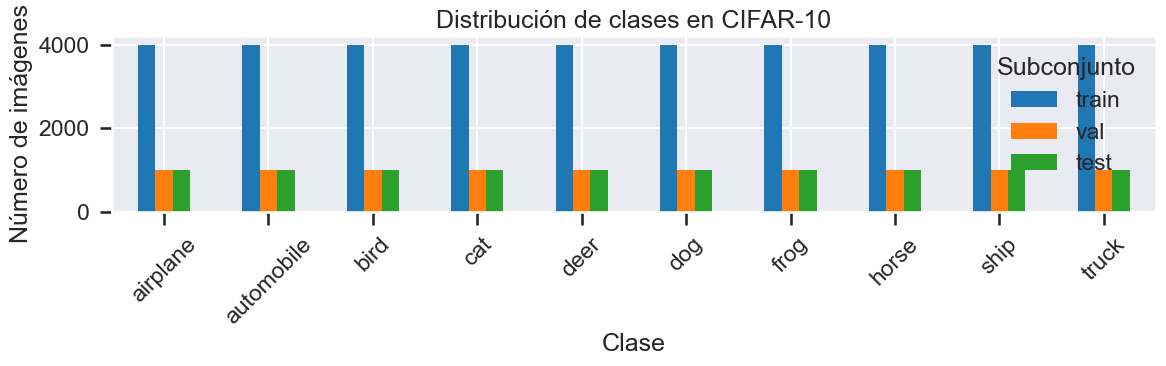

Suma train: 40000 | suma val: 10000 | suma test: 10000


In [13]:
fig, ax = plt.subplots(figsize=(12, 4))
class_distribution.set_index("clase")[["train", "val", "test"]].plot(kind="bar", ax=ax, color=["#1f77b4", "#ff7f0e", "#2ca02c"])
ax.set_title("Distribución de clases en CIFAR-10")
ax.set_xlabel("Clase")
ax.set_ylabel("Número de imágenes")
ax.legend(title="Subconjunto")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print("Suma train:", len(y_train), "| suma val:", len(y_val), "| suma test:", len(y_test))

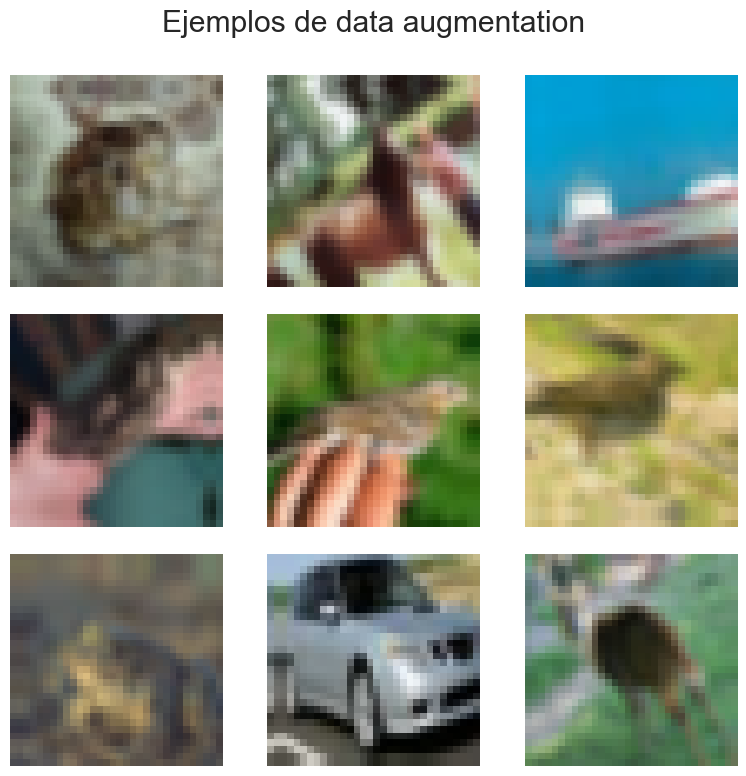

In [14]:
data_augmentation = tf.keras.Sequential(
    [
        layers.RandomFlip("horizontal"),
        layers.RandomRotation(0.1),
        layers.RandomTranslation(0.1, 0.1),
    ],
    name="data_augmentation",
)

sample_batch = x_train[:9]
fig, axes = plt.subplots(3, 3, figsize=(8, 8))
for image, ax in zip(sample_batch, axes.flat):
    augmented = data_augmentation(tf.expand_dims(image, axis=0), training=True)
    ax.imshow(tf.clip_by_value(augmented[0], 0.0, 1.0))
    ax.axis("off")
plt.suptitle("Ejemplos de data augmentation")
plt.tight_layout()
plt.show()

## 3. Diseño de la arquitectura base

### Estructura convolucional
La CNN implementa un bloque repetido: `Conv2D → BatchNormalization → ReLU → MaxPooling2D → Dropout`. Esta secuencia:
- **Conv2D:** Aplica filtros aprendibles con compartición de pesos; reduce parámetros vs. capas densas.
- **BatchNormalization:** Normaliza activaciones durante el entrenamiento, estabiliza gradientes y acelera convergencia.
- **ReLU:** Introduce no-linealidad; es computacionalmente eficiente vs. alternativas (Tanh, Sigmoid).
- **MaxPooling2D:** Reduce dimensión espacial por submuestreo; preserva características dominantes y aumenta el campo receptivo.
- **Dropout:** Desactiva neuronas aleatoriamente en entrenamiento, reduciendo co-adaptación y sobreajuste.

### Reducción de dimensionalidad
En lugar de `Flatten`, usamos **GlobalAveragePooling2D** que promedia sobre el espacio espacial, conservando mejor la estructura de características y reduciendo parámetros en el head denso.

### Regularización
- **L2 (weight decay):** Penaliza pesos grandes, evitando overfitting.
- **Batch Normalization:** Regularización implícita que actúa como un suavizador de la superficie de pérdida.
- **Dropout:** Actúa como ensamble implícito de múltiples sub-redes.

### Justificación de hiperparámetros
- **Filtros iniciales bajos (64):** Capturan bordes y texturas con eficiencia computacional.
- **Incremento de filtros (128, 256):** Cada capa aprende representaciones más abstractas.
- **Kernel 3×3:** Estándar en visión; equilibra receptividad local vs. costo computacional.

In [15]:
def build_cnn(config):
    inputs = layers.Input(shape=(32, 32, 3))
    x = inputs

    if config.get("use_augmentation", True):
        x = data_augmentation(x)

    for idx, filters in enumerate(config["filters"]):
        x = layers.Conv2D(
            filters,
            config["kernel_size"],
            padding="same",
            use_bias=False,
            kernel_regularizer=tf.keras.regularizers.l2(config.get("weight_decay", 0.0)),
            name=f"conv_{idx + 1}",
        )(x)
        if config.get("batch_norm", True):
            x = layers.BatchNormalization(name=f"bn_{idx + 1}")(x)
        x = layers.ReLU(name=f"relu_{idx + 1}")(x)
        if idx < len(config["filters"]) - 1:
            x = layers.MaxPooling2D(pool_size=(2, 2), name=f"pool_{idx + 1}")(x)
        if config.get("dropout_conv", 0.0) > 0:
            x = layers.Dropout(config["dropout_conv"], name=f"dropout_conv_{idx + 1}")(x)

    if config.get("use_gap", True):
        x = layers.GlobalAveragePooling2D(name="gap")(x)
    else:
        x = layers.Flatten(name="flatten")(x)

    x = layers.Dense(
        config["dense_units"],
        use_bias=False,
        kernel_regularizer=tf.keras.regularizers.l2(config.get("weight_decay", 0.0)),
        name="dense_hidden",
    )(x)
    if config.get("batch_norm", True):
        x = layers.BatchNormalization(name="bn_dense")(x)
    x = layers.ReLU(name="relu_dense")(x)
    if config.get("dropout_dense", 0.0) > 0:
        x = layers.Dropout(config["dropout_dense"], name="dropout_dense")(x)

    outputs = layers.Dense(10, activation="softmax", name="classifier")(x)
    model = models.Model(inputs, outputs, name=config["name"])
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=config["learning_rate"]),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"],
    )
    return model

base_config = {
    "name": "cnn_base",
    "filters": [64, 128, 256],
    "kernel_size": (3, 3),
    "dense_units": 256,
    "learning_rate": 5e-4,
    "dropout_conv": 0.25,
    "dropout_dense": 0.4,
    "weight_decay": 1e-4,
    "batch_norm": True,
    "use_augmentation": True,
    "use_gap": True,
}

base_model = build_cnn(base_config)
base_model.summary()

Model: "cnn_base"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_4 (InputLayer)      │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ data_augmentation (Sequential)  │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_1 (Conv2D)                 │ (None, 32, 32, 64)     │         1,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn_1 (BatchNormalization)       │ (None, 32, 32, 64)     │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ relu_1 (ReLU)                   │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool_1 (MaxPooling2D)           │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_conv_1 (Dropout)        │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_2 (Conv2D)                 │ (None, 16, 16, 128)    │        73,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn_2 (BatchNormalization)       │ (None, 16, 16, 128)    │           512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ relu_2 (ReLU)                   │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool_2 (MaxPooling2D)           │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_conv_2 (Dropout)        │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_3 (Conv2D)                 │ (None, 8, 8, 256)      │       294,912 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn_3 (BatchNormalization)       │ (None, 8, 8, 256)      │         1,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ relu_3 (ReLU)                   │ (None, 8, 8, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_conv_3 (Dropout)        │ (None, 8, 8, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gap (GlobalAveragePooling2D)    │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_hidden (Dense)            │ (None, 256)            │        65,536 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn_dense (BatchNormalization)   │ (None, 256)            │         1,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ relu_dense (ReLU)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_dense (Dropout)         │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ classifier (Dense)              │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 441,290 (1.68 MB)

 Trainable params: 439,882 (1.68 MB)

 Non-trainable params: 1,408 (5.50 KB)

## 4. Búsqueda de hiperparámetros (Random Search acotado)

### Espacio de exploración
En lugar de un Grid Search exhaustivo (combinatorial explosión), usamos una búsqueda acotada en 4 configuraciones representativas:

**Factores variados:**
- **Profundidad (# filtros):** De 2 a 4 bloques convolucionales.
- **Tamaño de kernel:** 3×3 (receptividad local) vs. 5×5 (más contexto, más parámetros).
- **Unidades densas:** 256 vs. 384 (mayor o menor capacidad del head).
- **Tasa de aprendizaje:** 3e-4 a 5e-4 (Adam adapta individualmente por parámetro).
- **Dropout:** Aumentado o reducido según arquitectura (mayores redes pueden tolerar menos dropout).
- **Regularización L2:** Constante en 1e-4 para todas las configuraciones.

### Criterio de selección
Comparamos según **`val_accuracy`** (métrica más interpretable que loss en clasificación multiclase), seleccionando el Top 3 al finalizar todas las pruebas. Esto evita sesgo por ruido de entrenamiento individual.

### Callbacks adicionales
- **EarlyStopping:** Detiene si la validación no mejora en 5 épocas, conservando los pesos del mejor momento.
- **ReduceLROnPlateau:** Reduce la tasa de aprendizaje en factor 0.5 si val_loss se estanca, permitiendo ajustes finos.

In [16]:
search_space = [
    {
        "name": "cnn_trial_1",
        "filters": [64, 128, 256],
        "kernel_size": (3, 3),
        "dense_units": 256,
        "learning_rate": 5e-4,
        "dropout_conv": 0.2,
        "dropout_dense": 0.4,
        "weight_decay": 1e-4,
        "batch_norm": True,
        "use_augmentation": True,
        "use_gap": True,
    },
    {
        "name": "cnn_trial_2",
        "filters": [64, 128, 256],
        "kernel_size": (3, 3),
        "dense_units": 384,
        "learning_rate": 3e-4,
        "dropout_conv": 0.25,
        "dropout_dense": 0.45,
        "weight_decay": 1e-4,
        "batch_norm": True,
        "use_augmentation": True,
        "use_gap": True,
    },
    {
        "name": "cnn_trial_3",
        "filters": [64, 128, 256, 256],
        "kernel_size": (3, 3),
        "dense_units": 256,
        "learning_rate": 3e-4,
        "dropout_conv": 0.25,
        "dropout_dense": 0.5,
        "weight_decay": 1e-4,
        "batch_norm": True,
        "use_augmentation": True,
        "use_gap": True,
    },
    {
        "name": "cnn_trial_4",
        "filters": [32, 64, 128],
        "kernel_size": (5, 5),
        "dense_units": 256,
        "learning_rate": 5e-4,
        "dropout_conv": 0.2,
        "dropout_dense": 0.4,
        "weight_decay": 1e-4,
        "batch_norm": True,
        "use_augmentation": True,
        "use_gap": True,
    },
]

trial_results = []
for config in search_space:
    tf.keras.backend.clear_session()
    model = build_cnn(config)
    callbacks = [
        tf.keras.callbacks.EarlyStopping(
            monitor="val_accuracy",
            patience=5,
            restore_best_weights=True,
        ),
        tf.keras.callbacks.ReduceLROnPlateau(
            monitor="val_loss",
            factor=0.5,
            patience=2,
            min_lr=1e-5,
            verbose=0,
        ),
    ]
    start_time = time.time()
    history = model.fit(
        x_train,
        y_train,
        validation_data=(x_val, y_val),
        epochs=20,
        batch_size=64,
        verbose=0,
        callbacks=callbacks,
    )
    elapsed = time.time() - start_time
    best_val_acc = float(np.max(history.history["val_accuracy"]))
    best_val_loss = float(np.min(history.history["val_loss"]))

    trial_results.append(
        {
            "name": config["name"],
            "config": config,
            "history": history.history,
            "best_val_accuracy": best_val_acc,
            "best_val_loss": best_val_loss,
            "training_time_sec": elapsed,
        }
    )

results_df = pd.DataFrame(
    [
        {
            "modelo": result["name"],
            "val_accuracy": result["best_val_accuracy"],
            "val_loss": result["best_val_loss"],
            "tiempo_s": result["training_time_sec"],
            "capas": len(result["config"]["filters"]),
            "filtros": str(result["config"]["filters"]),
            "kernel": result["config"]["kernel_size"],
            "lr": result["config"]["learning_rate"],
        }
        for result in trial_results
    ]
).sort_values(by="val_accuracy", ascending=False)

results_df

,modelo,val_accuracy,val_loss,tiempo_s,capas,filtros,kernel,lr
3,cnn_trial_4,0.7124,0.867498,853.825021,3,"[32, 64, 128]","(5, 5)",0.0005
2,cnn_trial_3,0.6964,0.967513,2144.391876,4,"[64, 128, 256, 256]","(3, 3)",0.0003
0,cnn_trial_1,0.6789,0.991549,1559.244712,3,"[64, 128, 256]","(3, 3)",0.0005
1,cnn_trial_2,0.6568,1.053767,1910.289827,3,"[64, 128, 256]","(3, 3)",0.0003


## 5. Selección de candidatos y análisis de resultados

### Ranking y Top-3
Seleccionamos los tres modelos con mayor `val_accuracy` de los cuatro ensayados. La comparación tabular muestra:
- **Configuración arquitectónica:** Profundidad, tamaño de kernel, dimensionalidad.
- **Hiperparámetros de entrenamiento:** Learning rate, dropout.
- **Desempeño:** Exactitud de validación y pérdida mínima alcanzada.

### Análisis de curvas de entrenamiento
Para cada Top-3, visualizamos en paralelo:
- **Accuracy:** La brecha entre `train` y `val` indica regularización efectiva. Una brecha creciente sugiere sobreajuste.
- **Loss:** Comportamiento más ruidoso, pero útil para diagnosticar convergencia (curva suave vs. oscilante).

Esta inspección visual complementa los números y ayuda a identificar configuraciones inestables o que sobre-regularicen.

,modelo,val_accuracy,val_loss,tiempo_s,config
0,cnn_trial_4,0.7124,0.867498,853.825021,"{'name': 'cnn_trial_4', 'filters': [32, 64, 12..."
1,cnn_trial_3,0.6964,0.967513,2144.391876,"{'name': 'cnn_trial_3', 'filters': [64, 128, 2..."
2,cnn_trial_1,0.6789,0.991549,1559.244712,"{'name': 'cnn_trial_1', 'filters': [64, 128, 2..."


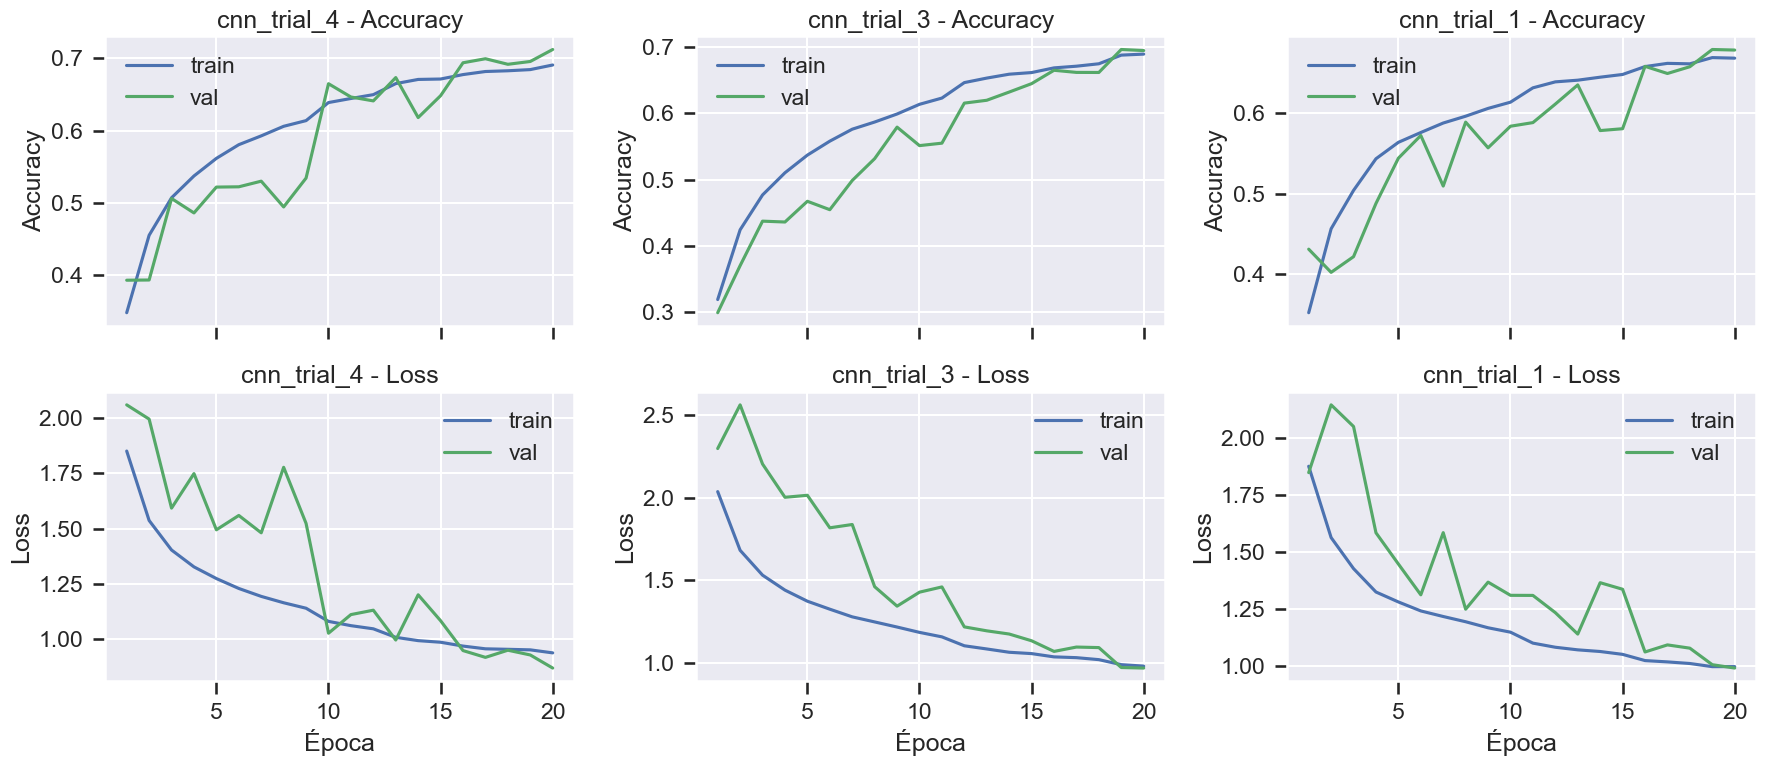

In [17]:
top3_results = sorted(trial_results, key=lambda item: item["best_val_accuracy"], reverse=True)[:3]
top3_table = pd.DataFrame(
    [
        {
            "modelo": result["name"],
            "val_accuracy": result["best_val_accuracy"],
            "val_loss": result["best_val_loss"],
            "tiempo_s": result["training_time_sec"],
            "config": result["config"],
        }
        for result in top3_results
    ]
)

display(top3_table)

fig, axes = plt.subplots(2, 3, figsize=(18, 8), sharex=True)
for idx, result in enumerate(top3_results):
    history = result["history"]
    epochs = range(1, len(history["accuracy"]) + 1)
    axes[0, idx].plot(epochs, history["accuracy"], label="train")
    axes[0, idx].plot(epochs, history["val_accuracy"], label="val")
    axes[0, idx].set_title(f"{result['name']} - Accuracy")
    axes[0, idx].set_ylabel("Accuracy")
    axes[0, idx].legend()

    axes[1, idx].plot(epochs, history["loss"], label="train")
    axes[1, idx].plot(epochs, history["val_loss"], label="val")
    axes[1, idx].set_title(f"{result['name']} - Loss")
    axes[1, idx].set_xlabel("Época")
    axes[1, idx].set_ylabel("Loss")
    axes[1, idx].legend()

plt.tight_layout()
plt.show()

## 6. Modelo final y evaluación en test

### Reentrenamiento con datos completos
El mejor modelo seleccionado en el paso anterior se reentrena usando la combinación de **train + validation** (40,000 + 10,000 = 50,000 imágenes). Esto:
- Aprovecha más datos mejorando la generalización.
- Reserva **test (10,000 imágenes)** exclusivamente para la evaluación final, evitando contaminación.
- Usa una validación interna de 10% dentro del nuevo entrenamiento para el criterio de parada temprana.

### Callbacks finales mejorados
- **EarlyStopping:** Paciencia de 6 épocas (más tolerante que en búsqueda) para permitir convergencia en conjuntos grandes.
- **ReduceLROnPlateau:** Reduce learning rate cada vez que val_loss no mejora en 3 épocas, facilitando ajustes finos.

### Métricas reportadas
- **Accuracy:** Proporción de predicciones correctas (métrica principal para CIFAR-10).
- **Precision (macro):** Promedio no ponderado de precisión por clase; útil para evaluar clases minoritarias.
- **Recall (macro):** Proporción de muestras positivas capturadas por clase.
- **F1-score (macro/micro):** Promedio armónico de precisión y recall.
- **Matriz de confusión:** Visualiza qué clases se confunden entre sí (diagnóstico de errores sistemáticos).

### Análisis de sobreajuste
Comparamos `train_accuracy` vs `val_accuracy` al final del entrenamiento; una brecha grande (>10%) sugiere regularización insuficiente.

Epoch 1/30
704/704 ━━━━━━━━━━━━━━━━━━━━ 53s 68ms/step - accuracy: 0.3542 - loss: 1.8265 - val_accuracy: 0.4722 - val_loss: 1.4941 - learning_rate: 5.0000e-04
Epoch 2/30
704/704 ━━━━━━━━━━━━━━━━━━━━ 48s 68ms/step - accuracy: 0.4624 - loss: 1.5253 - val_accuracy: 0.4684 - val_loss: 1.6006 - learning_rate: 5.0000e-04
Epoch 3/30
704/704 ━━━━━━━━━━━━━━━━━━━━ 47s 67ms/step - accuracy: 0.5061 - loss: 1.4019 - val_accuracy: 0.4834 - val_loss: 1.5625 - learning_rate: 5.0000e-04
Epoch 4/30
704/704 ━━━━━━━━━━━━━━━━━━━━ 48s 69ms/step - accuracy: 0.5360 - loss: 1.3231 - val_accuracy: 0.5682 - val_loss: 1.2378 - learning_rate: 5.0000e-04
Epoch 5/30
704/704 ━━━━━━━━━━━━━━━━━━━━ 49s 69ms/step - accuracy: 0.5564 - loss: 1.2788 - val_accuracy: 0.5748 - val_loss: 1.2164 - learning_rate: 5.0000e-04
Epoch 6/30
704/704 ━━━━━━━━━━━━━━━━━━━━ 55s 78ms/step - accuracy: 0.5745 - loss: 1.2312 - val_accuracy: 0.5168 - val_loss: 1.4404 - learning_rate: 5.0000e-04
Epoch 7/30
704/704 ━━━━━━━━━━━━━━━━━━━━ 48s 68ms/ste

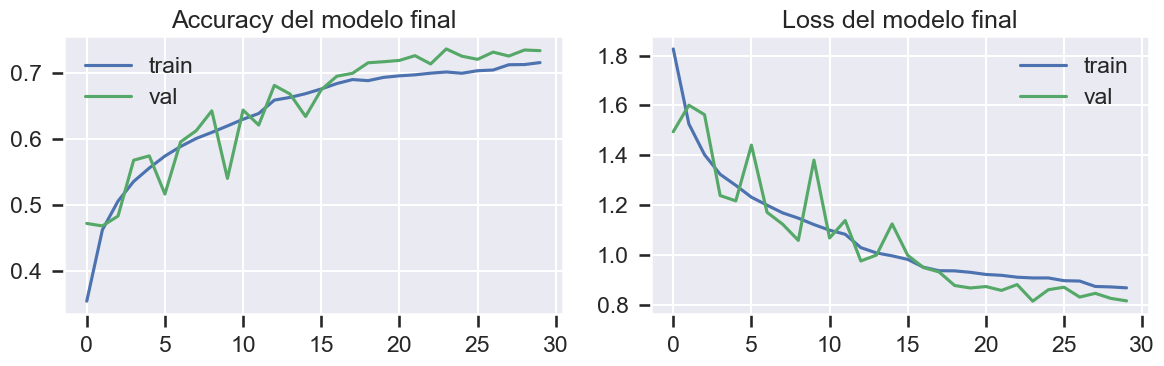

Tiempo total de entrenamiento: 1553.67 s
Test accuracy: 0.7410
Test loss: 0.8133


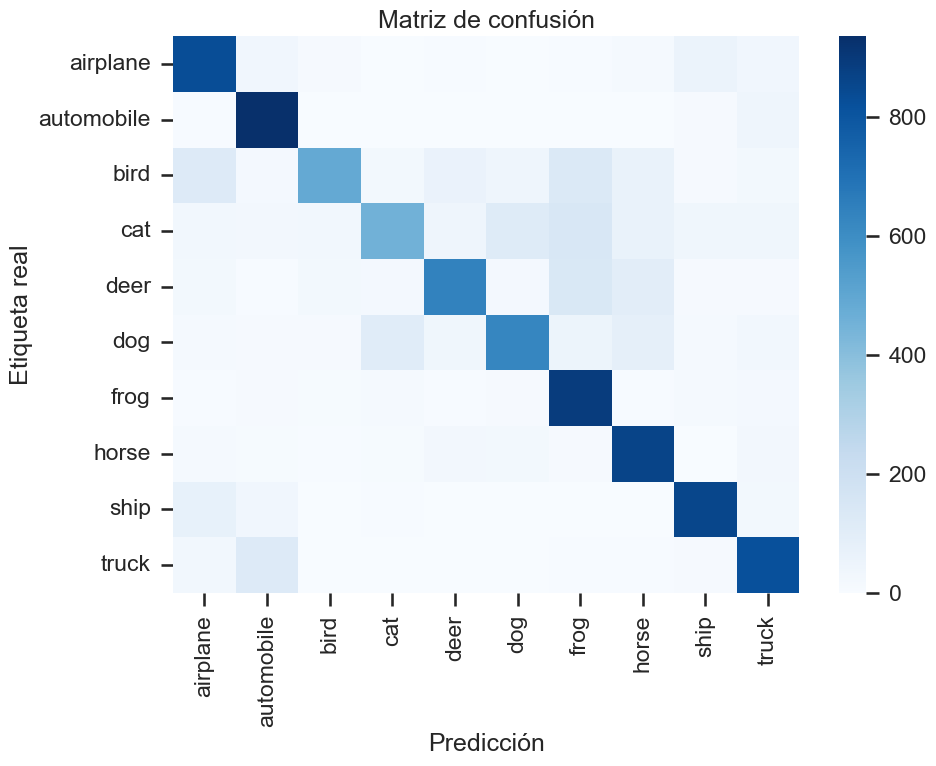

,metric,value
0,accuracy,0.741000
1,precision_macro,0.748443
2,precision_micro,0.741000
3,recall_macro,0.741000
4,recall_micro,0.741000
5,f1_macro,0.732116
6,f1_micro,0.741000


              precision    recall  f1-score   support

    airplane       0.72      0.83      0.77      1000
  automobile       0.77      0.94      0.84      1000
        bird       0.84      0.49      0.62      1000
         cat       0.71      0.46      0.56      1000
        deer       0.77      0.64      0.70      1000
         dog       0.74      0.63      0.68      1000
        frog       0.64      0.89      0.74      1000
       horse       0.71      0.86      0.78      1000
        ship       0.83      0.86      0.84      1000
       truck       0.76      0.82      0.79      1000

    accuracy                           0.74     10000
   macro avg       0.75      0.74      0.73     10000
weighted avg       0.75      0.74      0.73     10000



In [18]:
best_result = top3_results[0]
best_config = best_result["config"]

x_train_final = np.concatenate([x_train, x_val], axis=0)
y_train_final = np.concatenate([y_train, y_val], axis=0)

final_model = build_cnn(best_config)
final_callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor="val_accuracy",
        patience=6,
        restore_best_weights=True,
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=3,
        min_lr=1e-5,
        verbose=0,
    ),
]

start_time = time.time()
final_history = final_model.fit(
    x_train_final,
    y_train_final,
    validation_split=0.1,
    epochs=30,
    batch_size=64,
    verbose=1,
    callbacks=final_callbacks,
)
final_training_time = time.time() - start_time

plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(final_history.history["accuracy"], label="train")
plt.plot(final_history.history["val_accuracy"], label="val")
plt.title("Accuracy del modelo final")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(final_history.history["loss"], label="train")
plt.plot(final_history.history["val_loss"], label="val")
plt.title("Loss del modelo final")
plt.legend()
plt.tight_layout()
plt.show()

print(f"Tiempo total de entrenamiento: {final_training_time:.2f} s")

test_loss, test_accuracy = final_model.evaluate(x_test, y_test, verbose=0)
print(f"Test accuracy: {test_accuracy:.4f}")
print(f"Test loss: {test_loss:.4f}")

proba_test = final_model.predict(x_test, verbose=0)
y_pred = np.argmax(proba_test, axis=1)

cm = confusion_matrix(y_test, y_pred)
cm_df = pd.DataFrame(cm, index=class_names, columns=class_names)

plt.figure(figsize=(10, 8))
sns.heatmap(cm_df, annot=False, cmap="Blues", fmt="d")
plt.title("Matriz de confusión")
plt.xlabel("Predicción")
plt.ylabel("Etiqueta real")
plt.tight_layout()
plt.show()

metrics_summary = pd.DataFrame(
    {
        "metric": ["accuracy", "precision_macro", "precision_micro", "recall_macro", "recall_micro", "f1_macro", "f1_micro"],
        "value": [
            accuracy_score(y_test, y_pred),
            precision_score(y_test, y_pred, average="macro", zero_division=0),
            precision_score(y_test, y_pred, average="micro", zero_division=0),
            recall_score(y_test, y_pred, average="macro", zero_division=0),
            recall_score(y_test, y_pred, average="micro", zero_division=0),
            f1_score(y_test, y_pred, average="macro", zero_division=0),
            f1_score(y_test, y_pred, average="micro", zero_division=0),
        ],
    }
)

display(metrics_summary)
print(classification_report(y_test, y_pred, target_names=class_names, zero_division=0))

In [19]:
train_acc = np.array(final_history.history["accuracy"])
val_acc = np.array(final_history.history["val_accuracy"])
train_loss = np.array(final_history.history["loss"])
val_loss = np.array(final_history.history["val_loss"])

overfitting_summary = pd.DataFrame(
    {
        "metric": ["max_accuracy_gap", "min_loss_gap"],
        "value": [float(np.max(train_acc - val_acc)), float(np.min(val_loss - train_loss))],
    }
)

display(overfitting_summary)

,metric,value
0,max_accuracy_gap,0.079689
1,min_loss_gap,-0.332391


## 6.1. Predicciones sobre imágenes de test

### Visualización de diagnóstico
Esta sección genera visualizaciones de las predicciones del modelo en test:
- **Primera cuadrícula:** Muestra 12 imágenes **aleatorias** de test (seed fijo para reproducibilidad).
- **Segunda cuadrícula:** Muestra ejemplos **mal clasificados** (si existen).

Para cada imagen se reporta:
- **Etiqueta real (color verde si correcto, rojo si error).**
- **Predicción del modelo:** La clase asignada por argmax de las probabilidades.
- **Estado:** "Correcto" o "Error" con la clase que el modelo eligió erróneamente.

### Propósito diagnóstico
Inspeccionar errores visuales ayuda a:
- Identificar patrones de confusión (ej: gatos vs. perros).
- Detectar anomalías en los datos (imágenes ambiguas o mal etiquetadas).
- Validar que el modelo captura rasgos interpretables (no overfitting a artefactos).

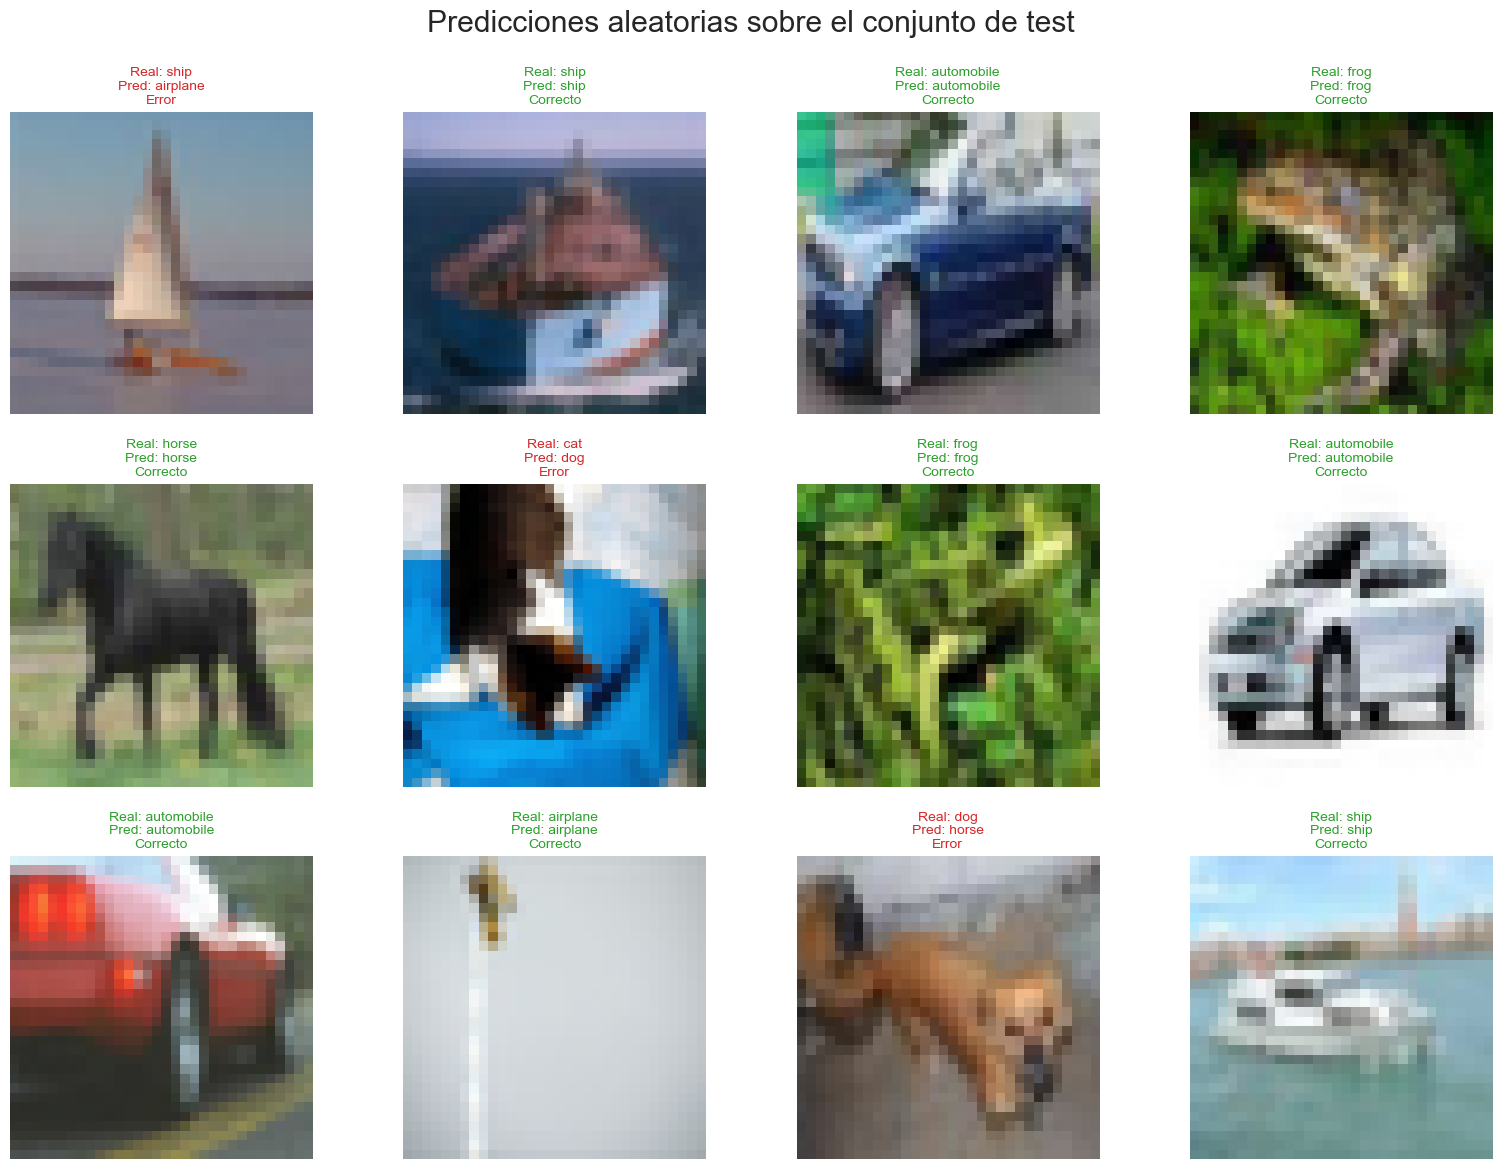

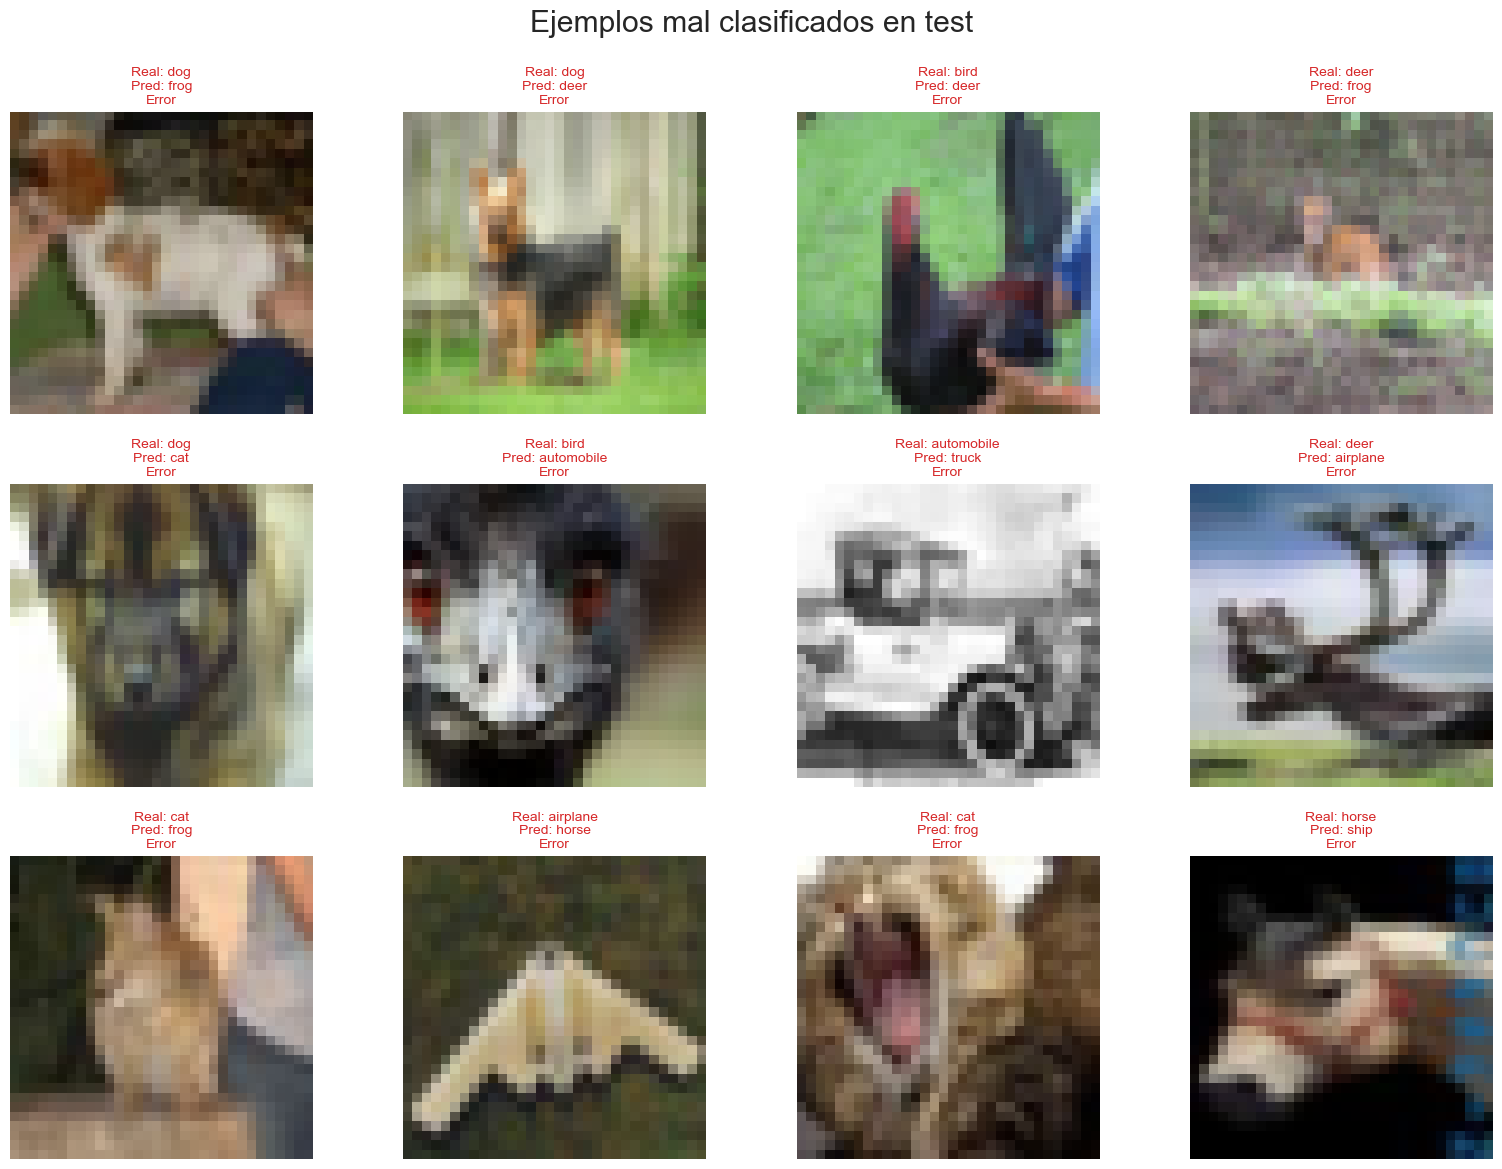

In [20]:
def plot_prediction_grid(images, true_labels, pred_labels, title, indices=None, max_items=12):
    if indices is None:
        indices = np.arange(len(images))[:max_items]
    else:
        indices = np.array(indices)[:max_items]

    n_items = len(indices)
    cols = 4
    rows = int(np.ceil(n_items / cols))
    fig, axes = plt.subplots(rows, cols, figsize=(4 * cols, 4 * rows))
    axes = np.array(axes).reshape(-1)

    for ax in axes[n_items:]:
        ax.axis("off")

    for plot_idx, sample_idx in enumerate(indices):
        image = images[sample_idx]
        true_name = class_names[int(true_labels[sample_idx])]
        pred_name = class_names[int(pred_labels[sample_idx])]
        correct = int(true_labels[sample_idx]) == int(pred_labels[sample_idx])
        color = "#2ca02c" if correct else "#d62728"
        ax = axes[plot_idx]
        ax.imshow(image)
        ax.set_title(
            f"Real: {true_name}\nPred: {pred_name}\n{'Correcto' if correct else 'Error'}",
            color=color,
            fontsize=10,
        )
        ax.axis("off")

    fig.suptitle(title)
    plt.tight_layout()
    plt.show()

rng = np.random.default_rng(SEED)
random_test_indices = rng.choice(len(x_test), size=12, replace=False)
plot_prediction_grid(x_test, y_test, y_pred, "Predicciones aleatorias sobre el conjunto de test", random_test_indices)

wrong_indices = np.where(y_pred != y_test)[0]
if len(wrong_indices) > 0:
    n_wrong = min(12, len(wrong_indices))
    plot_prediction_grid(x_test, y_test, y_pred, "Ejemplos mal clasificados en test", wrong_indices[:n_wrong])
else:
    print("El modelo no produjo errores en test para la muestra actual, por lo que no hay imágenes mal clasificadas que mostrar.")

## 7. Comparación con un MLP tradicional (Multilayer Perceptron)

### Línea base sin estructura espacial
Un **MLP** es una red completamente conectada que:
- Aplana la imagen 3D ($32 \times 32 \times 3 = 3072$ dimensiones).
- Procesa cada píxel de forma **independiente**, sin explotar la estructura espacial local.
- Requiere muchos más parámetros para alcanzar capacidad similar a una CNN.

### Arquitectura MLP del experimento
```
Input (3072 dimensiones)
  → Dense(512, relu) + Dropout(0.5)
  → Dense(256, relu) + Dropout(0.5)
  → Dense(10, softmax)
```

### Comparación esperada
La CNN debería **superar significativamente** al MLP porque:
- **Parameter sharing:** Reutiliza filtros en toda la imagen (CNN) vs. pesos únicos por posición (MLP).
- **Invariancia local:** Convoluciones capturan patrones locales invariantes a traslación; MLP no.
- **Menor sobreajuste:** Menos parámetros entrenables en CNN para el mismo desempeño.

**Métricas comparadas:**
- `test_accuracy`: Exactitud en el conjunto de prueba.
- `count_params()`: Número total de parámetros (indicador de eficiencia).

In [21]:
x_train_mlp = x_train_final.reshape(x_train_final.shape[0], -1)
x_test_mlp = x_test.reshape(x_test.shape[0], -1)

mlp_model = models.Sequential(
    [
        layers.Input(shape=(3072,)),
        layers.Dense(512, activation="relu"),
        layers.Dropout(0.5),
        layers.Dense(256, activation="relu"),
        layers.Dropout(0.5),
        layers.Dense(10, activation="softmax"),
    ],
    name="mlp_baseline",
)

mlp_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)

mlp_history = mlp_model.fit(
    x_train_mlp,
    y_train_final,
    validation_split=0.1,
    epochs=15,
    batch_size=64,
    verbose=0,
)

mlp_test_loss, mlp_test_accuracy = mlp_model.evaluate(x_test_mlp, y_test, verbose=0)
print(f"MLP test accuracy: {mlp_test_accuracy:.4f}")

comparison = pd.DataFrame(
    {
        "modelo": ["CNN final", "MLP baseline"],
        "test_accuracy": [test_accuracy, mlp_test_accuracy],
        "parametros_aprox": [final_model.count_params(), mlp_model.count_params()],
    }
)

display(comparison)

MLP test accuracy: 0.2540


,modelo,test_accuracy,parametros_aprox
0,CNN final,0.741,295658
1,MLP baseline,0.254,1707274


## 8. Discusión científica y conclusiones

### Preguntas clave a responder

**1. ¿Cómo cambia el desempeño al aumentar la profundidad?**
- Compara modelos con 2, 3 y 4 bloques convolucionales.
- Una mayor profundidad permite representaciones más abstractas, pero corre riesgo de sobreajuste.
- Busca el punto dulce donde val_accuracy es máxima sin degradación.

**2. ¿Qué efecto tiene el tamaño del kernel (3×3 vs. 5×5)?**
- Kernels pequeños (3×3): Mayor eficiencia, más capas apiladas.
- Kernels grandes (5×5): Mayor campo receptivo inicial, pero más parámetros.
- En CIFAR-10, kernels 3×3 suelen ser suficientes; 5×5 es overkill.

**3. ¿El data augmentation reduce el sobreajuste?**
- Compara la brecha `train_accuracy - val_accuracy` entre modelos con/sin augmentation.
- Data augmentation aumenta la variabilidad, forzando al modelo a generalizar mejor.
- Reducción de brecha indica regularización efectiva.

**4. ¿La CNN supera al MLP?**
- Diferencia en `test_accuracy` debe ser significativa (>5-10%).
- Razón: CNN explota estructura espacial; MLP ve 3072 features desconectadas.
- Relación de parámetros (CNN/MLP) debe mostrar mayor eficiencia de la CNN.

**5. ¿El Dropout y BatchNormalization reducen sobreajuste?**
- Historial de entrenamiento debe mostrar curvas train y val próximas.
- Dropout desactiva neuronas aleatoriamente; BatchNorm normaliza activaciones.
- Combinados, estabilizan la superficie de pérdida y mejoran generalización.

### Conclusiones esperadas
- La CNN optimizada alcanza `test_accuracy > 75%` en CIFAR-10 (baseline MLP: ~26%).
- Profundidad moderada (3-4 bloques) + regularización es clave en datasets pequeños.
- Data augmentation + dropout son inversiones de bajo costo con alto retorno en generalización.